<a href="https://colab.research.google.com/github/sahiser19/ST-554-/blob/main/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Concepts

1. We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V’s for
the example and whether/how they apply to your example: AMR surveillance using veterinary clinical data clearly embodies all five V’s of big data. The dataset is large (volume), continuously generated (velocity), heterogeneous (variety), imperfect and clinically subjective (veracity), and potentially highly impactful for public and animal health (value). The challenge is not simply storing the data, but transforming it into reliable and actionable insights for both the patients and the clinicians.
2. Read about the database we’ll use below (part IV). Give an example for each letter in the CRUD acronym
in the context of this database:
* C-Create by adding a new player or HOF event to the data.
* R-Read the data in a way that is meaningful...like selecting all the teams from a specific year.
* U-Update the existing data if needed or adding a flag to something like a HOF or player to create a new count or a new view of the data.
* D-Delete can be used to remove an incorrect data entry (like a manager or a player) that was entered into the table.
3. What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial
on the SELECT statement.): The HAVING clause is important because it is going to filter results on the back end of a group by statement. So basically it is a filter for data based on aggregated values (like a batting avg above a certain level, etc.). It's important to know the HAVING clause is after aggregation.

Part II - Simulation of a Sampling Distribution
We looked at using simulation to investigate the sampling distribution of ˆp in the notes. We’ll now look at the sampling distribution of the sample slope from an SLR model using simulation.

• Recall we assume the following model for SLR:

*   Yi = β0 + β1xi + Ei
where the Ei are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance σ2. Let’s assume σ2 = 1 for simplicity.
*   We can generate data from this model by assuming values for β0, β1, and n, along with a sequence
of x values via the following code:

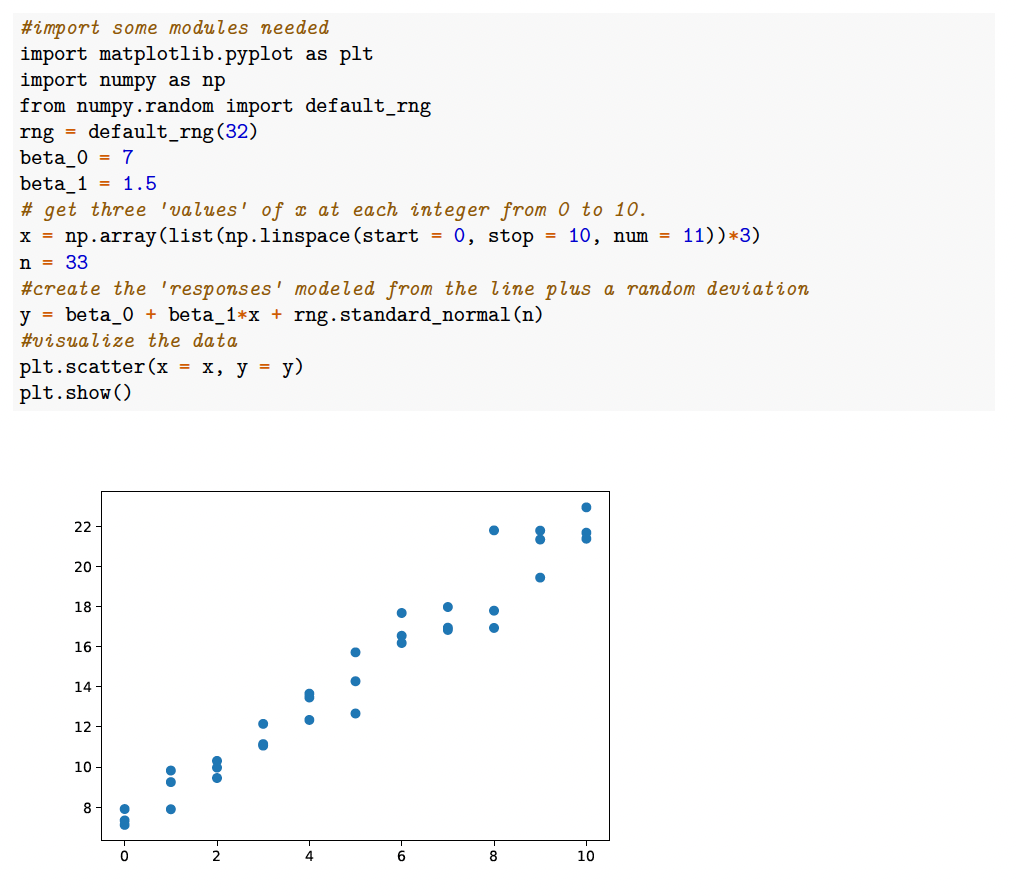

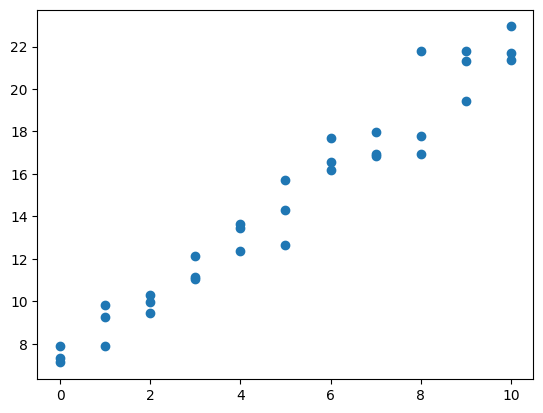

In [1]:
#P3.4 import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

In [17]:
import numpy as np
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression
## Same as Dr. Post's code above this code here is for "x"
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# Fixed design for the values and adjusting for the sklearn 2D input: 0–10, repeated 3 times (n = 33)
x = np.tile(np.linspace(0, 10, 11), 3)
X = x.reshape(-1, 1)
n = len(x)

In [18]:
# now we need to repeat, create and store values for "y"
slopes = [] ##this is where I'll store "y"

for i in range(5000): ##so repeat 5000 times and create a bit of new "noise" each time via the rsn() code
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # Fit regression to record/store the values created
    model = LinearRegression()
    model.fit(X, y)

    # Store slope for determining "best"
    slopes.append(model.coef_[0])

slopes = np.array(slopes)

Now we can use sklearn to obtain the estimate for the slope (and save that value) as we did earlier in the course.


*   Repeat the above process 5000 times.
*   Generate the y values using the code with rng.standard_normal()
*   Find the ‘best’ slope via sklearn
*   Save that slope in some object

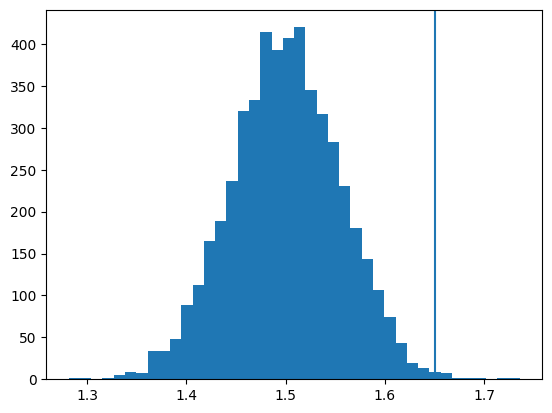

np.float64(0.0038)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# slopes is my 5000 slope estimates from the code above

# Histogram of the 5000 sample slope values
plt.hist(slopes, bins=40)
plt.axvline(1.65)   # reference line that I can adjust set at 1.65 for this assignment
plt.show()

# 2) Approximate P(sample slope > 1.65)
p_hat = np.mean(slopes > 1.65)   # proportion above 1.65
p_hat

We can use the many values of the sample slope as an approximation to the sampling distribution.

*  Create a histogram of the sample slope values you found. (3 pts)
of the sample slope!
*  Use your sampling distribution to approximate the probability of observing a sample slope larger
than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65. (3
pts)
*  Give an interpretation: The p_hat is .0038 which means that seeing a slope greater than 1.65 is extremely unlikely just by chance or noise alone. If we do see it then it either means that our true slope (1.5) is wrong or we should play the lottery because the chances are miniscule.

In [21]:
p_hat

np.float64(0.0038)

Part III: Big Data Examples & Rare Events

5. Consider this article about bias in machine learning models
* Pick an example in the article and briefly outline the issue around the data used to fit the model: The article discusses how an image recognition model trained on data depicting cooking and household scenes disproportionately associated kitchens with women. Because the training data contained more images of women in kitchens than of men, the model learned that association not because it was true that a woman comes with the kitchen, but because the dataset encoded that gender stereotype.

* Describe how we might augment the data or otherwise account for the bias in that situation: To augment something like this we have to expand the representation by purposefully inflating or accomodating for rare events. If pictures of men in kitchens are rare and our goal is for our model to have an even/balanced association then we need to purposefully weigh those "man in kitchen" events higher or include a higher frequency within our sample for training.
6. Consider this article about big data usage in the Earth Sciences
* Choose one of the three major areas the paper discusses. Summarize the use of big data there: Oceanography. One of my favorite examples here is using big data to try to understand why the King crab fishery "disappeared" from 2019-2023. By integrating diverse observational sources with data-driven and physics-based models, oceanographers can analyze the dynamics of fishery behavior (like the King crab), surface and deep waters, trace carbon cycles, and examine how ocean processes influence weather, ecosystems, and climate on global scales.
* Are there any biases or other missing data that might affect results? Some datasets in oceanography span decades and others are much shorter. Temporal gaps in addition to limited geographical coverage in observations can influence the detection of long-term trends (aka climate signals) or rare events. When datasets are patched together, inconsistencies in temporal coverage can bias analyses. Understanding how or if this gap data is imputed is also incredibly important.
7. Read through this short article: Article
* Can you think of another variable or scenario where understanding rare events is important? I think of the movie "The Big Short" here where modeling extreme market movements from disparate data sources that are peripherally related can identify a rare event like a stock market crash or rapid currency devaluations. But, most financial firms are more concenred with the day-to-day price changes that are small and follow familiar patterns. The "normal" models will usually fail to see the "tail/rare" events even though they have massive impacts on portfolios, economies, and financial institutions.

Part IV - Querying a database

In [22]:
#Part IV importing the table
import sqlite3
import pandas as pd

db_path = "lahman_1871-2022.sqlite"   # must match the uploaded filename
con = sqlite3.connect(db_path)

In [24]:
#Part 4 Q8
tables_df = pd.read_sql_query("""
SELECT name AS table_name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""", con)

tables_df

,table_name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


In [25]:
#Part 4 Q9
teams_2015 = pd.read_sql_query("""
SELECT *
FROM Teams
WHERE yearID = 2015;
""", con)

teams_2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


In [26]:
#Part 4 Q10
hof_players = pd.read_sql_query("""
SELECT playerID,
       yearID AS year_inducted,
       category
FROM HallOfFame
WHERE inducted = 'Y';
""", con)

hof_players

,playerID,year_inducted,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


In [27]:
#Part 4 Q11
pit_managers = pd.read_sql_query("""
SELECT DISTINCT playerID
FROM Managers
WHERE teamID = 'PIT';
""", con)

pit_managers

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


In [28]:
#Part 4 Q12
hof_managers = pd.read_sql_query("""
SELECT DISTINCT m.playerID
FROM Managers AS m
JOIN HallOfFame AS h
  ON m.playerID = h.playerID
WHERE h.inducted = 'Y';
""", con)

# Count programmatically
num_hof_managers = hof_managers['playerID'].nunique()

hof_managers, num_hof_managers

(     playerID
 0   alstowa01
 1   andersp01
 2   ansonca01
 3   applilu01
 4   baineha01
 ..        ...
 92  willidi02
 93  willite01
 94  wrighge01
 95  wrighha01
 96  youngcy01
 
 [97 rows x 1 columns],
 97)

In [29]:
#Part 4 Q13a
hof_manager_seasons = pd.read_sql_query("""
SELECT m.playerID, m.G, m.W, m.L
FROM Managers AS m
JOIN (
    SELECT DISTINCT playerID
    FROM HallOfFame
    WHERE inducted = 'Y'
) AS h
ON m.playerID = h.playerID;
""", con)

hof_manager_seasons.head()

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83


In [30]:
#Part 4 Q13b
hof_totals = (
    hof_manager_seasons
    .groupby("playerID", as_index=False)[["W", "L"]]
    .sum()
)

In [31]:
#Part 4 Q13c
hof_totals["win_pct"] = hof_totals["W"] / (hof_totals["W"] + hof_totals["L"])

In [32]:
#Part 4 Q13d
hof_totals_sorted = hof_totals.sort_values("win_pct", ascending=False)

hof_totals_sorted

,playerID,W,L,win_pct
75,simmote01,1,0,1.000000
94,wrighge01,59,25,0.702381
78,spaldal01,78,47,0.624000
57,mccarjo99,2125,1333,0.614517
19,comisch01,840,541,0.608255
...,...,...,...,...
8,bottoji01,21,56,0.272727
3,applilu01,10,30,0.250000
4,baineha01,1,3,0.250000
86,wagneho01,1,4,0.200000


Rewriting the PD code as SQL to see if we can get the same table as above.

In [33]:
import sqlite3
import pandas as pd

db_path = "lahman_1871-2022.sqlite"
con = sqlite3.connect(db_path)

hof_manager_totals_sql = pd.read_sql_query("""
SELECT
    m.playerID,
    SUM(m.G) AS G,
    SUM(m.W) AS W,
    SUM(m.L) AS L,
    CAST(SUM(m.W) AS REAL) / (SUM(m.W) + SUM(m.L)) AS win_pct
FROM Managers AS m
JOIN (
    SELECT DISTINCT playerID
    FROM HallOfFame
    WHERE inducted = 'Y'
) AS h
ON m.playerID = h.playerID
GROUP BY m.playerID
ORDER BY win_pct DESC;
""", con)

hof_manager_totals_sql

,playerID,G,W,L,win_pct
0,simmote01,1,1,0,1.000000
1,wrighge01,85,59,25,0.702381
2,spaldal01,126,78,47,0.624000
3,mccarjo99,3487,2125,1333,0.614517
4,comisch01,1410,840,541,0.608255
...,...,...,...,...,...
92,bottoji01,78,21,56,0.272727
93,applilu01,40,10,30,0.250000
94,baineha01,4,1,3,0.250000
95,wagneho01,5,1,4,0.200000
